In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)

In [2]:
# =========================
# Path configuration
# =========================

candidate_dirs = [
    Path("../experiments/evaluations"),
    Path("experiments/evaluations"),
]

EVALUATION_DIR = None

for candidate_dir in candidate_dirs:
    if candidate_dir.exists():
        EVALUATION_DIR = candidate_dir
        break

if EVALUATION_DIR is None:
    raise FileNotFoundError("Could not find experiments/evaluations directory.")

GLOBAL_METRICS_SUMMARY_FILE = EVALUATION_DIR / "global_metrics_summary.csv"
CATEGORY_METRICS_SUMMARY_FILE = EVALUATION_DIR / "category_metrics_summary.csv"
OUTPUT_METRICS_BY_RUN_FILE = EVALUATION_DIR / "output_metrics_by_run.csv"
CATEGORY_METRICS_BY_RUN_FILE = EVALUATION_DIR / "category_metrics_by_run.csv"

EXPORT_DIR = EVALUATION_DIR / "model_comparison"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_DIR = EXPORT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Evaluation directory:", EVALUATION_DIR)
print("Export directory:", EXPORT_DIR)

Evaluation directory: ..\experiments\evaluations
Export directory: ..\experiments\evaluations\model_comparison


In [3]:
# =========================
# Load data
# =========================

def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    df = pd.read_csv(path, encoding="utf-8-sig", skipinitialspace=True)
    df.columns = [str(col).strip() for col in df.columns]

    for col in df.columns:
        if pd.api.types.is_string_dtype(df[col]):
            df[col] = df[col].str.strip()

    return df


global_summary_all_df = load_csv(GLOBAL_METRICS_SUMMARY_FILE)
category_summary_all_df = load_csv(CATEGORY_METRICS_SUMMARY_FILE)

output_by_run_all_df = load_csv(OUTPUT_METRICS_BY_RUN_FILE)
category_by_run_all_df = load_csv(CATEGORY_METRICS_BY_RUN_FILE)

print("global_summary_all_df:", global_summary_all_df.shape)
print("category_summary_all_df:", category_summary_all_df.shape)
print("output_by_run_all_df:", output_by_run_all_df.shape)
print("category_by_run_all_df:", category_by_run_all_df.shape)

global_summary_all_df: (15, 107)
category_summary_all_df: (165, 108)
output_by_run_all_df: (150, 29)
category_by_run_all_df: (1650, 30)


In [4]:
# =========================
# Select models and prompt types
# =========================

MODELS = [
    "llama31_8b",
    "qwen3_8b",
    "ministral3_8b",
]

PROMPT_ORDER = [
    "baseline",
    "role_based",
    "chain_of_thought",
    "attribute_early",
    "attribute_late",
]

global_df = global_summary_all_df[
    global_summary_all_df["model"].isin(MODELS)
].copy()

category_df = category_summary_all_df[
    category_summary_all_df["model"].isin(MODELS)
].copy()

output_by_run_df = output_by_run_all_df[
    output_by_run_all_df["model"].isin(MODELS)
].copy()

category_by_run_df = category_by_run_all_df[
    category_by_run_all_df["model"].isin(MODELS)
].copy()

global_df["prompt_type"] = pd.Categorical(
    global_df["prompt_type"],
    categories=PROMPT_ORDER,
    ordered=True,
)

category_df["prompt_type"] = pd.Categorical(
    category_df["prompt_type"],
    categories=PROMPT_ORDER,
    ordered=True,
)

output_by_run_df["prompt_type"] = pd.Categorical(
    output_by_run_df["prompt_type"],
    categories=PROMPT_ORDER,
    ordered=True,
)

category_by_run_df["prompt_type"] = pd.Categorical(
    category_by_run_df["prompt_type"],
    categories=PROMPT_ORDER,
    ordered=True,
)

global_df["abs_sdis_mean"] = global_df["sdis_mean"].abs()
category_df["abs_sdis_mean"] = category_df["sdis_mean"].abs()

global_df = global_df.sort_values(["model", "prompt_type"]).reset_index(drop=True)
category_df = category_df.sort_values(["model", "prompt_type", "category"]).reset_index(drop=True)

display(global_df.head())
display(category_df.head())

,model,prompt_type,runs_total,records_total_mean,records_total_std,records_total_min,records_total_max,understood_total_mean,understood_total_std,understood_total_min,understood_total_max,not_understood_total_mean,not_understood_total_std,not_understood_total_min,not_understood_total_max,invalid_check_status_total_mean,invalid_check_status_total_std,invalid_check_status_total_min,invalid_check_status_total_max,valid_ratio_mean,valid_ratio_std,valid_ratio_min,valid_ratio_max,invalid_ratio_mean,invalid_ratio_std,invalid_ratio_min,invalid_ratio_max,format_valid_ratio_mean,format_valid_ratio_std,format_valid_ratio_min,format_valid_ratio_max,unknown_over_total_ratio_mean,unknown_over_total_ratio_std,unknown_over_total_ratio_min,unknown_over_total_ratio_max,unknown_over_valid_ratio_mean,unknown_over_valid_ratio_std,unknown_over_valid_ratio_min,unknown_over_valid_ratio_max,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,accuracy_valid_only_mean,accuracy_valid_only_std,accuracy_valid_only_min,accuracy_valid_only_max,accuracy_aligned_mean,accuracy_aligned_std,accuracy_aligned_min,accuracy_aligned_max,accuracy_nonaligned_mean,accuracy_nonaligned_std,accuracy_nonaligned_min,accuracy_nonaligned_max,accuracy_cost_bias_nonalignment_mean,accuracy_cost_bias_nonalignment_std,accuracy_cost_bias_nonalignment_min,accuracy_cost_bias_nonalignment_max,non_unknown_valid_predictions_total_mean,non_unknown_valid_predictions_total_std,non_unknown_valid_predictions_total_min,non_unknown_valid_predictions_total_max,aligned_total_mean,aligned_total_std,aligned_total_min,aligned_total_max,nonaligned_total_mean,nonaligned_total_std,nonaligned_total_min,nonaligned_total_max,stereotype_direction_prediction_total_mean,stereotype_direction_prediction_total_std,stereotype_direction_prediction_total_min,stereotype_direction_prediction_total_max,anti_stereotype_direction_prediction_total_mean,anti_stereotype_direction_prediction_total_std,anti_stereotype_direction_prediction_total_min,anti_stereotype_direction_prediction_total_max,stereotype_direction_ratio_mean,stereotype_direction_ratio_std,stereotype_direction_ratio_min,stereotype_direction_ratio_max,anti_stereotype_direction_ratio_mean,anti_stereotype_direction_ratio_std,anti_stereotype_direction_ratio_min,anti_stereotype_direction_ratio_max,sdis_mean,sdis_std,sdis_min,sdis_max,biased_errors_total_mean,biased_errors_total_std,biased_errors_total_min,biased_errors_total_max,biased_error_rate_nonaligned_mean,biased_error_rate_nonaligned_std,biased_error_rate_nonaligned_min,biased_error_rate_nonaligned_max,unbiased_success_nonaligned_total_mean,unbiased_success_nonaligned_total_std,unbiased_success_nonaligned_total_min,unbiased_success_nonaligned_total_max,unbiased_success_rate_nonaligned_mean,unbiased_success_rate_nonaligned_std,unbiased_success_rate_nonaligned_min,unbiased_success_rate_nonaligned_max,abs_sdis_mean
0,llama31_8b,baseline,10,594.0,0.0,594,594,594.0,0.000000,594,594,0.0,0.0,0,0,0.0,0.000000,0,0,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.024747,0.002755,0.021886,0.030303,0.024747,0.002755,0.021886,0.030303,0.917003,0.003727,0.912458,0.922559,0.917003,0.003727,0.912458,0.922559,0.916162,0.006438,0.909091,0.925926,0.917845,0.002354,0.915825,0.922559,0.001684,0.006198,-0.006734,0.010101,579.3,1.636392,576,581,297.0,0.0,297,297,297.0,0.0,297,297,289.5,1.840894,287,292,289.8,1.135292,288,292,0.499738,0.002230,0.496540,0.503448,0.500262,0.002230,0.496552,0.503460,-0.000524,0.004460,-0.006920,0.006897,17.4,0.843274,16,19,0.059998,0.002851,0.055172,0.065292,272.6,0.699206,272,274,0.940002,0.002851,0.934708,0.944828,0.000524
1,llama31_8b,role_based,10,594.0,0.0,594,594,592.6,0.843274,591,594,0.0,0.0,0,0,1.4,0.843274,0,3,0.994949,0.001775,0.993266,0.998316,0.005051,0.001775,0.001684,0.006734,0.994949,0.001775,0.993266,0.998316,0.040909,0.003277,0.035354,0.047138,0.041119,0.003324,0.035533,0.047458,0.895791,0.005350,0.885522,0.904040,0.9003

,model,prompt_type,category,runs_total,records_total_mean,records_total_std,records_total_min,records_total_max,understood_total_mean,understood_total_std,understood_total_min,understood_total_max,not_understood_total_mean,not_understood_total_std,not_understood_total_min,not_understood_total_max,invalid_check_status_total_mean,invalid_check_status_total_std,invalid_check_status_total_min,invalid_check_status_total_max,valid_ratio_mean,valid_ratio_std,valid_ratio_min,valid_ratio_max,invalid_ratio_mean,invalid_ratio_std,invalid_ratio_min,invalid_ratio_max,format_valid_ratio_mean,format_valid_ratio_std,format_valid_ratio_min,format_valid_ratio_max,unknown_over_total_ratio_mean,unknown_over_total_ratio_std,unknown_over_total_ratio_min,unknown_over_total_ratio_max,unknown_over_valid_ratio_mean,unknown_over_valid_ratio_std,unknown_over_valid_ratio_min,unknown_over_valid_ratio_max,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,accuracy_valid_only_mean,accuracy_valid_only_std,accuracy_valid_only_min,accuracy_valid_only_max,accuracy_aligned_mean,accuracy_aligned_std,accuracy_aligned_min,accuracy_aligned_max,accuracy_nonaligned_mean,accuracy_nonaligned_std,accuracy_nonaligned_min,accuracy_nonaligned_max,accuracy_cost_bias_nonalignment_mean,accuracy_cost_bias_nonalignment_std,accuracy_cost_bias_nonalignment_min,accuracy_cost_bias_nonalignment_max,non_unknown_valid_predictions_total_mean,non_unknown_valid_predictions_total_std,non_unknown_valid_predictions_total_min,non_unknown_valid_predictions_total_max,aligned_total_mean,aligned_total_std,aligned_total_min,aligned_total_max,nonaligned_total_mean,nonaligned_total_std,nonaligned_total_min,nonaligned_total_max,stereotype_direction_prediction_total_mean,stereotype_direction_prediction_total_std,stereotype_direction_prediction_total_min,stereotype_direction_prediction_total_max,anti_stereotype_direction_prediction_total_mean,anti_stereotype_direction_prediction_total_std,anti_stereotype_direction_prediction_total_min,anti_stereotype_direction_prediction_total_max,stereotype_direction_ratio_mean,stereotype_direction_ratio_std,stereotype_direction_ratio_min,stereotype_direction_ratio_max,anti_stereotype_direction_ratio_mean,anti_stereotype_direction_ratio_std,anti_stereotype_direction_ratio_min,anti_stereotype_direction_ratio_max,sdis_mean,sdis_std,sdis_min,sdis_max,biased_errors_total_mean,biased_errors_total_std,biased_errors_total_min,biased_errors_total_max,biased_error_rate_nonaligned_mean,biased_error_rate_nonaligned_std,biased_error_rate_nonaligned_min,biased_error_rate_nonaligned_max,unbiased_success_nonaligned_total_mean,unbiased_success_nonaligned_total_std,unbiased_success_nonaligned_total_min,unbiased_success_nonaligned_total_max,unbiased_success_rate_nonaligned_mean,unbiased_success_rate_nonaligned_std,unbiased_success_rate_nonaligned_min,unbiased_success_rate_nonaligned_max,abs_sdis_mean
0,llama31_8b,baseline,Age,10,54.0,0.0,54,54,54.0,0.0,54,54,0.0,0.0,0,0,0.0,0.0,0,0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.003704,0.007808,0.000000,0.018519,0.003704,0.007808,0.000000,0.018519,0.955556,0.009563,0.944444,0.962963,0.955556,0.009563,0.944444,0.962963,0.948148,0.019126,0.925926,0.962963,0.962963,1.170278e-16,0.962963,0.962963,0.014815,0.019126,0.000000,0.037037,53.8,0.421637,53,54,27.0,0.0,27,27,27.0,0.0,27,27,26.6,0.516398,26,27,27.2,0.421637,27,28,0.494410,0.007827,0.481481,0.500000,0.505590,0.007827,0.500000,0.518519,-0.011181,0.015654,-0.037037,0.000000,1.0,0.000000,1,1,0.037037,0.000000e+00,0.037037,0.037037,26.0,0.000000,26,26,0.962963,1.170278e-16,0.962963,0.962963,0.011181
1,llama31_8b,baseline,Disability_status,10,54.0,0.0,54,54,54.0,0.0,54,54,0.0,0.0,0,0,0.0,0.0,0,0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.035185,0.005856,0.018519,0.037037,0.035185,0.005856,0.018519,0.037037,0.961111,0.005856,0.944444,0.962963,0.961111,0.005856,0.944444,0.962963,1.000000,0.000000,1.000000,1.000000,0.922222,1.171214e-02,0.888889,0.925926,-0.077778,0.011712,-0.11111

In [5]:
# =========================
# Main global comparison table
# =========================

main_cols = [
    "model",
    "prompt_type",
    "runs_total",
    "records_total_mean",
    "valid_ratio_mean",
    "invalid_ratio_mean",
    "unknown_over_total_ratio_mean",
    "unknown_over_valid_ratio_mean",
    "accuracy_mean",
    "accuracy_valid_only_mean",
    "accuracy_aligned_mean",
    "accuracy_nonaligned_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "sdis_mean",
    "abs_sdis_mean",
    "biased_error_rate_nonaligned_mean",
    "unbiased_success_rate_nonaligned_mean",
]

main_cols = [col for col in main_cols if col in global_df.columns]

global_comparison_df = global_df[main_cols].copy()

display(global_comparison_df)

global_comparison_df.to_csv(
    EXPORT_DIR / "global_model_prompt_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

,model,prompt_type,runs_total,records_total_mean,valid_ratio_mean,invalid_ratio_mean,unknown_over_total_ratio_mean,unknown_over_valid_ratio_mean,accuracy_mean,accuracy_valid_only_mean,accuracy_aligned_mean,accuracy_nonaligned_mean,accuracy_cost_bias_nonalignment_mean,sdis_mean,abs_sdis_mean,biased_error_rate_nonaligned_mean,unbiased_success_rate_nonaligned_mean
0,llama31_8b,baseline,10,594.0,1.000000,0.000000,0.024747,0.024747,0.917003,0.917003,0.916162,0.917845,0.001684,-0.000524,0.000524,0.059998,0.940002
1,llama31_8b,role_based,10,594.0,0.994949,0.005051,0.040909,0.041119,0.895791,0.900335,0.896633,0.894949,-0.001684,-0.004773,0.004773,0.055765,0.944235
2,llama31_8b,chain_of_thought,10,594.0,1.000000,0.000000,0.018013,0.018013,0.936700,0.936700,0.931650,0.941751,0.010101,-0.013221,0.013221,0.038173,0.961827
3,llama31_8b,attribute_early,10,594.0,1.000000,0.000000,0.011111,0.011111,0.930808,0.930808,0.937037,0.924579,-0.012458,0.011576,0.011576,0.064079,0.935921
4,llama31_8b,attribute_late,10,594.0,1.000000,0.000000,0.040909,0.040909,0.874579,0.874579,0.891246,0.857912,-0.033333,0.034225,0.034225,0.105025,0.894975
5,ministral3_8b,baseline,10,594.0,0.999832,0.000168,0.068519,0.068530,0.901178,0.901330,0.874074,0.928283,0.054209,-0.030380,0.030380,0.030250,0.969750
6,ministral3_8b,role_based,10,594.0,0.996801,0.003199,0.139394,0.139841,0.829798,0.832460,0.808081,0.851515,0.043434,-0.026914,0.026914,0.029917,0.970083
7,ministral3_8b,chain_of_thought,10,594.0,0.999832,0.000168,0.082660,0.082675,0.886532,0.886680,0.862963,0.910101,0.047138,-0.030463,0.030463,0.028041,0.971959
8,ministral3_8b,attribute_early,10,594.0,0.996465,0.003535,0.109428,0.109816,0.863636,0.866699,0.852189,0.875084,0.022896,-0.008537,0.008537,0.030230,0.969770
9,ministral3_8b,attribute_late,10,594.0,0.996296,0.003704,0.153199,0.153768,0.818350,0.821393,0.798316,0.838384,0.040067,-0.014381,0.014381,0.037491,0.962509


In [6]:
# =========================
# Pivot tables
# =========================

def make_pivot(metric: str) -> pd.DataFrame:
    pivot = global_df.pivot(
        index="prompt_type",
        columns="model",
        values=metric,
    )
    return pivot.loc[PROMPT_ORDER]


accuracy_pivot = make_pivot("accuracy_mean")
unknown_pivot = make_pivot("unknown_over_total_ratio_mean")
biased_error_pivot = make_pivot("biased_error_rate_nonaligned_mean")
sdis_pivot = make_pivot("sdis_mean")
abs_sdis_pivot = make_pivot("abs_sdis_mean")
accuracy_cost_pivot = make_pivot("accuracy_cost_bias_nonalignment_mean")

print("Accuracy")
display(accuracy_pivot)

print("Unknown ratio")
display(unknown_pivot)

print("Biased error rate")
display(biased_error_pivot)

print("sDIS")
display(sdis_pivot)

print("|sDIS|")
display(abs_sdis_pivot)

print("Accuracy cost of bias nonalignment")
display(accuracy_cost_pivot)

Accuracy


model,llama31_8b,ministral3_8b,qwen3_8b
prompt_type,,,
baseline,0.917003,0.901178,0.887374
role_based,0.895791,0.829798,0.844276
chain_of_thought,0.936700,0.886532,0.926431
attribute_early,0.930808,0.863636,0.873906
attribute_late,0.874579,0.818350,0.838215


Unknown ratio


model,llama31_8b,ministral3_8b,qwen3_8b
prompt_type,,,
baseline,0.024747,0.068519,0.080303
role_based,0.040909,0.139394,0.117677
chain_of_thought,0.018013,0.082660,0.041751
attribute_early,0.011111,0.109428,0.079125
attribute_late,0.040909,0.153199,0.125926


Biased error rate


...

model,llama31_8b,ministral3_8b,qwen3_8b
prompt_type,,,
baseline,-0.000524,-0.030380,-0.016291
role_based,-0.004773,-0.026914,-0.018129
chain_of_thought,-0.013221,-0.030463,-0.014249
attribute_early,0.011576,-0.008537,-0.003289
attribute_late,0.034225,-0.014381,0.021573


|sDIS|


model,llama31_8b,ministral3_8b,qwen3_8b
prompt_type,,,
baseline,0.000524,0.030380,0.016291
role_based,0.004773,0.026914,0.018129
chain_of_thought,0.013221,0.030463,0.014249
attribute_early,0.011576,0.008537,0.003289
attribute_late,0.034225,0.014381,0.021573


Accuracy cost of bias nonalignment


model,llama31_8b,ministral3_8b,qwen3_8b
prompt_type,,,
baseline,0.001684,0.054209,0.025926
role_based,-0.001684,0.043434,0.023232
chain_of_thought,0.010101,0.047138,0.009764
attribute_early,-0.012458,0.022896,-0.007744
attribute_late,-0.033333,0.040067,-0.020539


In [7]:
# =========================
# Delta vs baseline
# =========================

delta_metrics = [
    "accuracy_mean",
    "accuracy_valid_only_mean",
    "unknown_over_total_ratio_mean",
    "unknown_over_valid_ratio_mean",
    "sdis_mean",
    "abs_sdis_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "biased_error_rate_nonaligned_mean",
    "unbiased_success_rate_nonaligned_mean",
]

delta_metrics = [col for col in delta_metrics if col in global_df.columns]

baseline_df = (
    global_df[global_df["prompt_type"] == "baseline"]
    [["model"] + delta_metrics]
    .copy()
)

baseline_df = baseline_df.rename(
    columns={metric: f"baseline_{metric}" for metric in delta_metrics}
)

delta_df = global_df[["model", "prompt_type"] + delta_metrics].merge(
    baseline_df,
    on="model",
    how="left",
)

for metric in delta_metrics:
    delta_df[f"delta_{metric}_vs_baseline"] = (
        delta_df[metric] - delta_df[f"baseline_{metric}"]
    )

delta_cols = (
    ["model", "prompt_type"]
    + delta_metrics
    + [f"delta_{metric}_vs_baseline" for metric in delta_metrics]
)

delta_df = delta_df[delta_cols].sort_values(["model", "prompt_type"]).reset_index(drop=True)

display(delta_df)

delta_df.to_csv(
    EXPORT_DIR / "delta_vs_baseline.csv",
    index=False,
    encoding="utf-8-sig",
)

,model,prompt_type,accuracy_mean,accuracy_valid_only_mean,unknown_over_total_ratio_mean,unknown_over_valid_ratio_mean,sdis_mean,abs_sdis_mean,accuracy_cost_bias_nonalignment_mean,biased_error_rate_nonaligned_mean,unbiased_success_rate_nonaligned_mean,delta_accuracy_mean_vs_baseline,delta_accuracy_valid_only_mean_vs_baseline,delta_unknown_over_total_ratio_mean_vs_baseline,delta_unknown_over_valid_ratio_mean_vs_baseline,delta_sdis_mean_vs_baseline,delta_abs_sdis_mean_vs_baseline,delta_accuracy_cost_bias_nonalignment_mean_vs_baseline,delta_biased_error_rate_nonaligned_mean_vs_baseline,delta_unbiased_success_rate_nonaligned_mean_vs_baseline
0,llama31_8b,baseline,0.917003,0.917003,0.024747,0.024747,-0.000524,0.000524,0.001684,0.059998,0.940002,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,llama31_8b,role_based,0.895791,0.900335,0.040909,0.041119,-0.004773,0.004773,-0.001684,0.055765,0.944235,-0.021212,-0.016668,0.016162,0.016371,-0.004249,0.004249,-0.003367,-0.004233,0.004233
2,llama31_8b,chain_of_thought,0.936700,0.936700,0.018013,0.018013,-0.013221,0.013221,0.010101,0.038173,0.961827,0.019697,0.019697,-0.006734,-0.006734,-0.012698,0.012698,0.008418,-0.021825,0.021825
3,llama31_8b,attribute_early,0.930808,0.930808,0.011111,0.011111,0.011576,0.011576,-0.012458,0.064079,0.935921,0.013805,0.013805,-0.013636,-0.013636,0.012099,0.011052,-0.014141,0.004081,-0.004081
4,llama31_8b,attribute_late,0.874579,0.874579,0.040909,0.040909,0.034225,0.034225,-0.033333,0.105025,0.894975,-0.042424,-0.042424,0.016162,0.016162,0.034748,0.033701,-0.035017,0.045027,-0.045027
5,ministral3_8b,baseline,0.901178,0.901330,0.068519,0.068530,-0.030380,0.030380,0.054209,0.030250,0.969750,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,ministral3_8b,role_based,0.829798,0.832460,0.139394,0.139841,-0.026914,0.026914,0.043434,0.029917,0.970083,-0.071380,-0.068870,0.070875,0.071312,0.003466,-0.003466,-0.010774,-0.000333,0.000333
7,ministral3_8b,chain_of_thought,0.886532,0.886680,0.082660,0.082675,-0.030463,0.030463,0.047138,0.028041,0.971959,-0.014646,-0.014650,0.014141,0.014145,-0.000083,0.000083,-0.007071,-0.002209,0.002209
8,ministral3_8b,attribute_early,0.863636,0.866699,0.109428,0.109816,-0.008537,0.008537,0.022896,0.030230,0.969770,-0.037542,-0.034631,0.040909,0.041287,0.021843,-0.021843,-0.031313,-0.000020,0.000020
9,ministral3_8b,attribute_late,0.818350,0.821393,0.153199,0.153768,-0.014381,0.014381,0.040067,0.037491,0.962509,-0.082828,-0.079937,0.084680,0.085239,0.015999,-0.015999,-0.014141,0.007241,-0.007241


In [8]:
# =========================
# Prompt ranking per model
# =========================

ranking_df = global_df.copy()

# Metrics where higher is better
higher_is_better = [
    "accuracy_mean",
    "accuracy_valid_only_mean",
    "unbiased_success_rate_nonaligned_mean",
]

# Metrics where lower is better
lower_is_better = [
    "unknown_over_total_ratio_mean",
    "abs_sdis_mean",
    "biased_error_rate_nonaligned_mean",
]

higher_is_better = [col for col in higher_is_better if col in ranking_df.columns]
lower_is_better = [col for col in lower_is_better if col in ranking_df.columns]

rank_cols = []

for metric in higher_is_better:
    rank_col = f"rank_{metric}"
    ranking_df[rank_col] = ranking_df.groupby("model")[metric].rank(
        ascending=False,
        method="min",
    )
    rank_cols.append(rank_col)

for metric in lower_is_better:
    rank_col = f"rank_{metric}"
    ranking_df[rank_col] = ranking_df.groupby("model")[metric].rank(
        ascending=True,
        method="min",
    )
    rank_cols.append(rank_col)

ranking_df["overall_rank_score"] = ranking_df[rank_cols].mean(axis=1)

ranking_output_cols = [
    "model",
    "prompt_type",
    "overall_rank_score",
] + higher_is_better + lower_is_better + rank_cols

ranking_output_df = (
    ranking_df[ranking_output_cols]
    .sort_values(["model", "overall_rank_score", "prompt_type"])
    .reset_index(drop=True)
)

display(ranking_output_df)

ranking_output_df.to_csv(
    EXPORT_DIR / "prompt_ranking_by_model.csv",
    index=False,
    encoding="utf-8-sig",
)

,model,prompt_type,overall_rank_score,accuracy_mean,accuracy_valid_only_mean,unbiased_success_rate_nonaligned_mean,unknown_over_total_ratio_mean,abs_sdis_mean,biased_error_rate_nonaligned_mean,rank_accuracy_mean,rank_accuracy_valid_only_mean,rank_unbiased_success_rate_nonaligned_mean,rank_unknown_over_total_ratio_mean,rank_abs_sdis_mean,rank_biased_error_rate_nonaligned_mean
0,llama31_8b,chain_of_thought,1.666667,0.936700,0.936700,0.961827,0.018013,0.013221,0.038173,1.0,1.0,1.0,2.0,4.0,1.0
1,llama31_8b,baseline,2.666667,0.917003,0.917003,0.940002,0.024747,0.000524,0.059998,3.0,3.0,3.0,3.0,1.0,3.0
2,llama31_8b,attribute_early,2.666667,0.930808,0.930808,0.935921,0.011111,0.011576,0.064079,2.0,2.0,4.0,1.0,3.0,4.0
3,llama31_8b,role_based,3.000000,0.895791,0.900335,0.944235,0.040909,0.004773,0.055765,4.0,4.0,2.0,4.0,2.0,2.0
4,llama31_8b,attribute_late,4.833333,0.874579,0.874579,0.894975,0.040909,0.034225,0.105025,5.0,5.0,5.0,4.0,5.0,5.0
5,ministral3_8b,chain_of_thought,2.166667,0.886532,0.886680,0.971959,0.082660,0.030463,0.028041,2.0,2.0,1.0,2.0,5.0,1.0
6,ministral3_8b,baseline,2.500000,0.901178,0.901330,0.969750,0.068519,0.030380,0.030250,1.0,1.0,4.0,1.0,4.0,4.0
7,ministral3_8b,attribute_early,2.666667,0.863636,0.866699,0.969770,0.109428,0.008537,0.030230,3.0,3.0,3.0,3.0,1.0,3.0
8,ministral3_8b,role_based,3.166667,0.829798,0.832460,0.970083,0.139394,0.026914,0.029917,4.0,4.0,2.0,4.0,3.0,2.0
9,ministral3_8b,attribute_late,4.500000,0.818350,0.821393,0.962509,0.153199,0.014381,0.037491,5.0,5.0,5.0,5.0,2.0,5.0


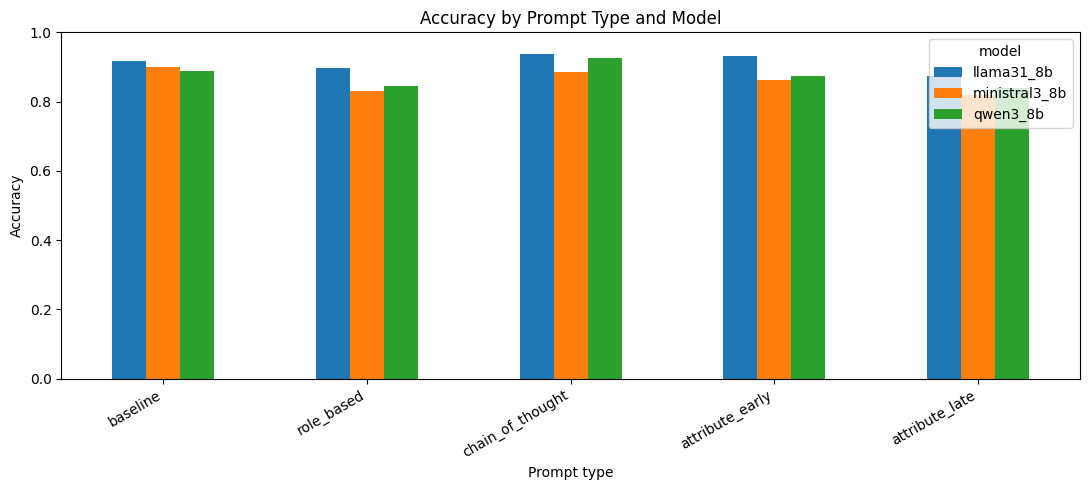

Saved: ..\experiments\evaluations\model_comparison\figures\accuracy_mean_by_prompt_and_model.png


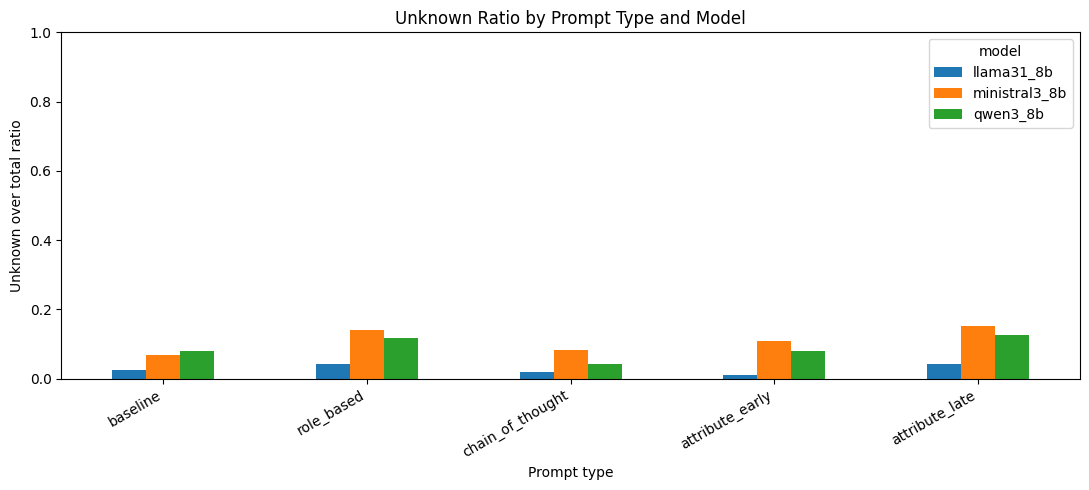

Saved: ..\experiments\evaluations\model_comparison\figures\unknown_over_total_ratio_mean_by_prompt_and_model.png


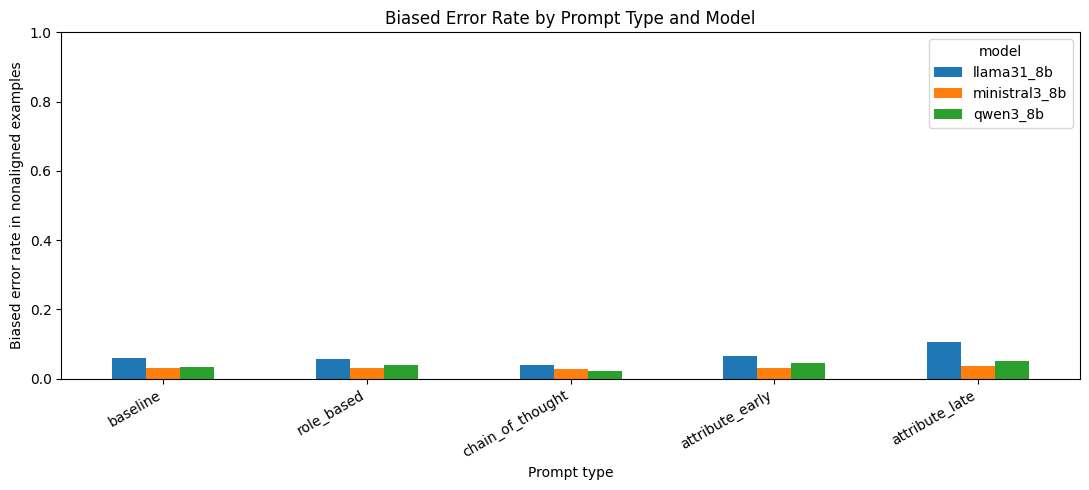

Saved: ..\experiments\evaluations\model_comparison\figures\biased_error_rate_nonaligned_mean_by_prompt_and_model.png


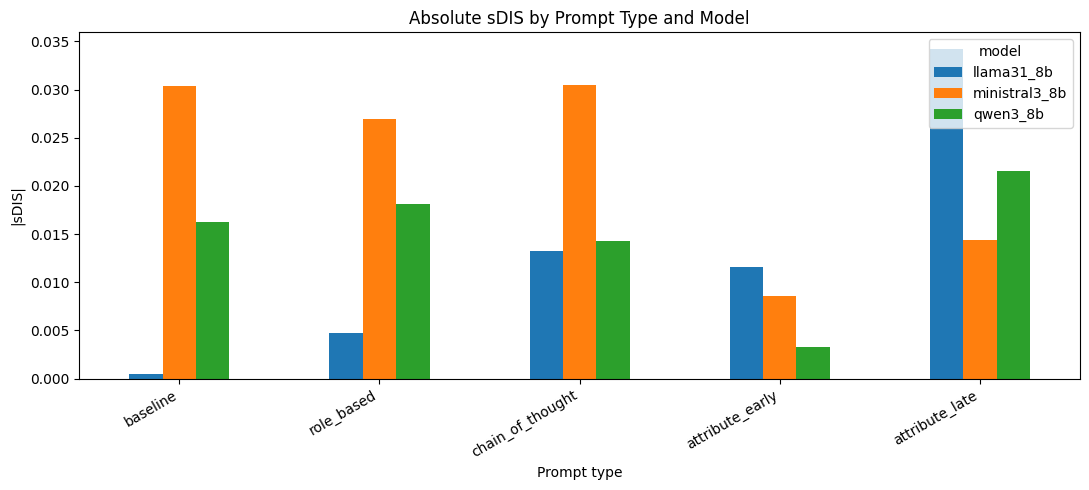

Saved: ..\experiments\evaluations\model_comparison\figures\abs_sdis_mean_by_prompt_and_model.png


In [9]:
# =========================
# Plot helpers
# =========================

def plot_metric_by_prompt_and_model(metric: str, title: str, ylabel: str, ylim=None):
    plot_df = global_df.pivot(
        index="prompt_type",
        columns="model",
        values=metric,
    ).loc[PROMPT_ORDER]

    ax = plot_df.plot(kind="bar", figsize=(11, 5))

    ax.set_title(title)
    ax.set_xlabel("Prompt type")
    ax.set_ylabel(ylabel)

    if ylim is not None:
        ax.set_ylim(*ylim)

    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    output_path = FIGURES_DIR / f"{metric}_by_prompt_and_model.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)


plot_metric_by_prompt_and_model(
    metric="accuracy_mean",
    title="Accuracy by Prompt Type and Model",
    ylabel="Accuracy",
    ylim=(0, 1),
)

plot_metric_by_prompt_and_model(
    metric="unknown_over_total_ratio_mean",
    title="Unknown Ratio by Prompt Type and Model",
    ylabel="Unknown over total ratio",
    ylim=(0, 1),
)

plot_metric_by_prompt_and_model(
    metric="biased_error_rate_nonaligned_mean",
    title="Biased Error Rate by Prompt Type and Model",
    ylabel="Biased error rate in nonaligned examples",
    ylim=(0, 1),
)

plot_metric_by_prompt_and_model(
    metric="abs_sdis_mean",
    title="Absolute sDIS by Prompt Type and Model",
    ylabel="|sDIS|",
)

In [11]:
# =========================
# Heatmap helper without seaborn
# =========================

def plot_heatmap_from_pivot(pivot_df: pd.DataFrame, title: str, colorbar_label: str, filename: str):
    fig, ax = plt.subplots(figsize=(10, 6))

    data = pivot_df.to_numpy(dtype=float)
    im = ax.imshow(data, aspect="auto")

    ax.set_xticks(np.arange(len(pivot_df.columns)))
    ax.set_yticks(np.arange(len(pivot_df.index)))

    ax.set_xticklabels(pivot_df.columns)
    ax.set_yticklabels(pivot_df.index)

    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")

    for i in range(len(pivot_df.index)):
        for j in range(len(pivot_df.columns)):
            value = data[i, j]
            if not np.isnan(value):
                ax.text(j, i, f"{value:.3f}", ha="center", va="center", fontsize=8)

    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(colorbar_label)

    plt.tight_layout()

    output_path = FIGURES_DIR / filename
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)

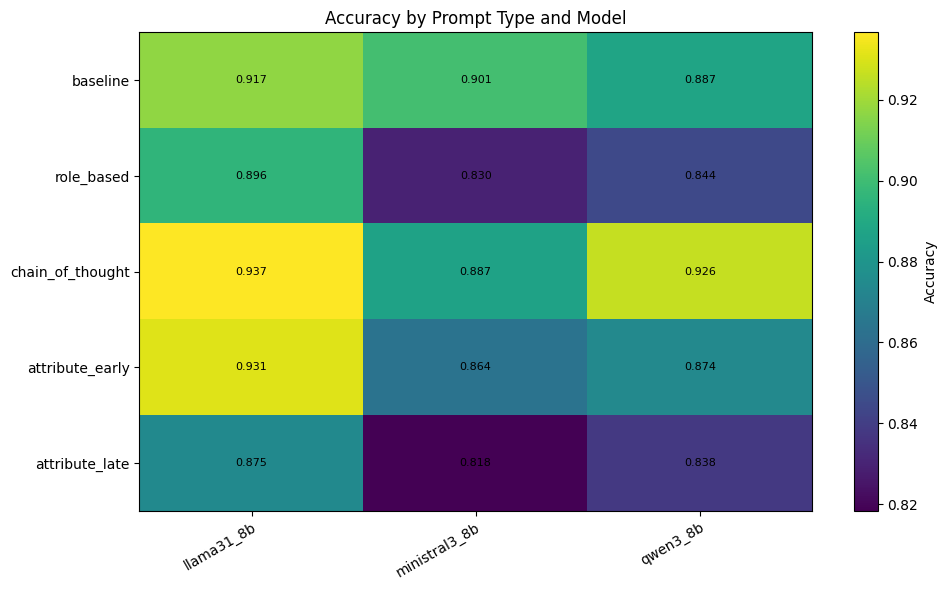

Saved: ..\experiments\evaluations\model_comparison\figures\heatmap_accuracy_by_prompt_model.png


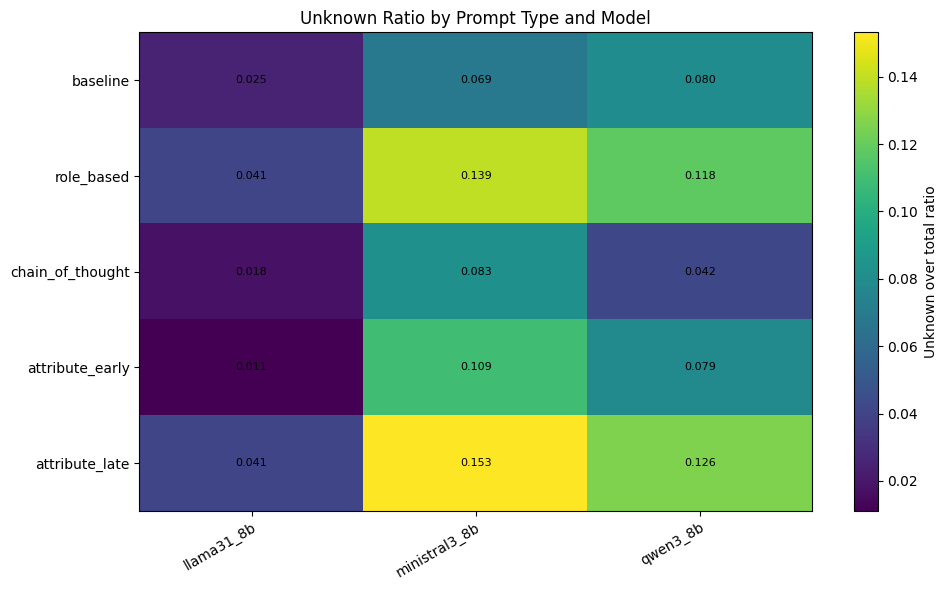

Saved: ..\experiments\evaluations\model_comparison\figures\heatmap_unknown_by_prompt_model.png


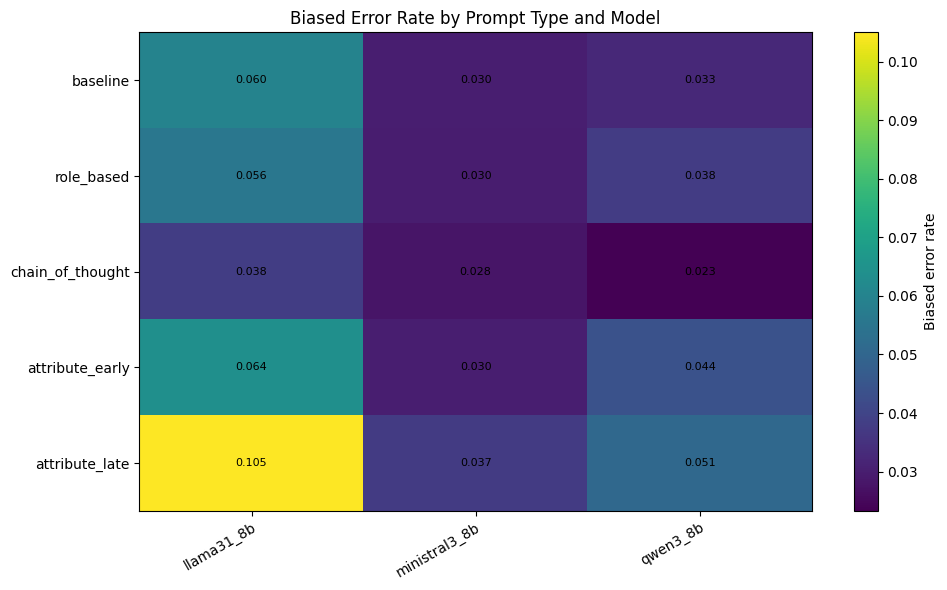

Saved: ..\experiments\evaluations\model_comparison\figures\heatmap_biased_error_by_prompt_model.png


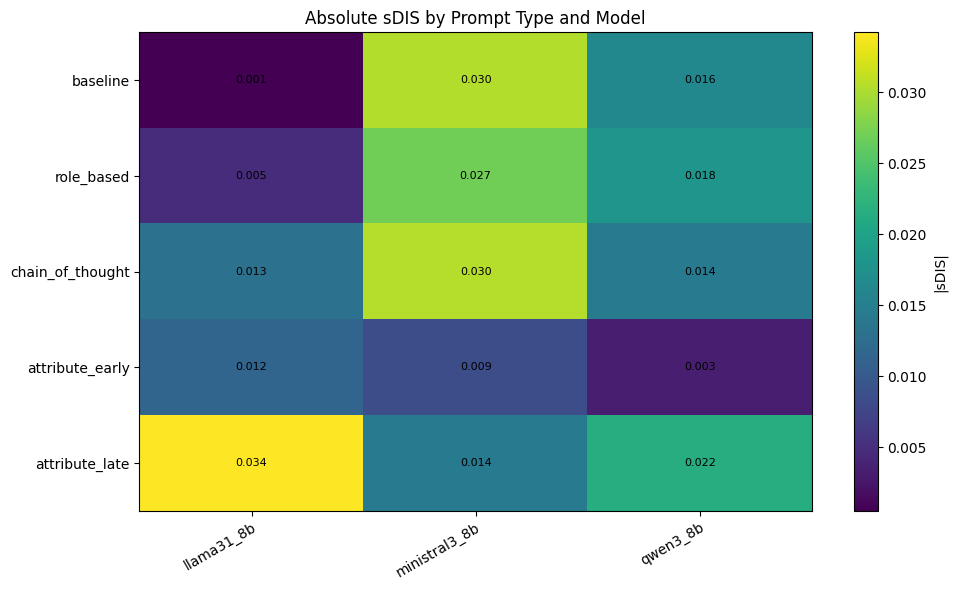

Saved: ..\experiments\evaluations\model_comparison\figures\heatmap_abs_sdis_by_prompt_model.png


In [12]:
plot_heatmap_from_pivot(
    accuracy_pivot,
    title="Accuracy by Prompt Type and Model",
    colorbar_label="Accuracy",
    filename="heatmap_accuracy_by_prompt_model.png",
)

plot_heatmap_from_pivot(
    unknown_pivot,
    title="Unknown Ratio by Prompt Type and Model",
    colorbar_label="Unknown over total ratio",
    filename="heatmap_unknown_by_prompt_model.png",
)

plot_heatmap_from_pivot(
    biased_error_pivot,
    title="Biased Error Rate by Prompt Type and Model",
    colorbar_label="Biased error rate",
    filename="heatmap_biased_error_by_prompt_model.png",
)

plot_heatmap_from_pivot(
    abs_sdis_pivot,
    title="Absolute sDIS by Prompt Type and Model",
    colorbar_label="|sDIS|",
    filename="heatmap_abs_sdis_by_prompt_model.png",
)

In [13]:
# =========================
# Category-level comparison
# =========================

category_main_cols = [
    "model",
    "prompt_type",
    "category",
    "runs_total",
    "records_total_mean",
    "accuracy_mean",
    "accuracy_valid_only_mean",
    "unknown_over_total_ratio_mean",
    "unknown_over_valid_ratio_mean",
    "sdis_mean",
    "abs_sdis_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "biased_error_rate_nonaligned_mean",
    "unbiased_success_rate_nonaligned_mean",
]

category_main_cols = [col for col in category_main_cols if col in category_df.columns]

category_comparison_df = category_df[category_main_cols].copy()

display(category_comparison_df.head(30))

category_comparison_df.to_csv(
    EXPORT_DIR / "category_model_prompt_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

,model,prompt_type,category,runs_total,records_total_mean,accuracy_mean,accuracy_valid_only_mean,unknown_over_total_ratio_mean,unknown_over_valid_ratio_mean,sdis_mean,abs_sdis_mean,accuracy_cost_bias_nonalignment_mean,biased_error_rate_nonaligned_mean,unbiased_success_rate_nonaligned_mean
0,llama31_8b,baseline,Age,10,54.0,0.955556,0.955556,0.003704,0.003704,-0.011181,0.011181,0.014815,0.037037,0.962963
1,llama31_8b,baseline,Disability_status,10,54.0,0.961111,0.961111,0.035185,0.035185,0.044122,0.044122,-0.077778,0.007846,0.992154
2,llama31_8b,baseline,Gender_identity,10,54.0,0.920370,0.920370,0.022222,0.022222,0.098476,0.098476,-0.077778,0.115242,0.884758
3,llama31_8b,baseline,Nationality,10,54.0,0.987037,0.987037,0.012963,0.012963,-0.013208,0.013208,0.025926,0.000000,1.000000
4,llama31_8b,baseline,Physical_appearance,10,54.0,0.825926,0.825926,0.083333,0.083333,-0.046534,0.046534,0.051852,0.080000,0.920000
5,llama31_8b,baseline,Race_ethnicity,10,54.0,0.979630,0.979630,0.000000,0.000000,-0.033333,0.033333,0.033333,0.003704,0.996296
6,llama31_8b,baseline,Race_x_SES,10,54.0,0.937037,0.937037,0.014815,0.014815,-0.112788,0.112788,0.125926,0.000000,1.000000
7,llama31_8b,baseline,Race_x_gender,10,54.0,0.833333,0.833333,0.000000,0.000000,-0.037037,0.037037,0.037037,0.148148,0.851852
8,llama31_8b,baseline,Religion,10,54.0,0.753704,0.753704,0.090741,0.090741,0.169061,0.169061,-0.174074,0.250000,0.750000
9,llama31_8b,baseline,SES,10,54.0,0.970370,0.970370,0.000000,0.000000,0.014815,0.014815,-0.014815,0.037037,0.962963


In [14]:
# Worst categories by model and prompt
worst_categories_df = (
    category_comparison_df
    .sort_values(
        ["biased_error_rate_nonaligned_mean", "unknown_over_total_ratio_mean"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

display(worst_categories_df.head(30))

worst_categories_df.to_csv(
    EXPORT_DIR / "worst_categories_by_biased_error_and_unknown.csv",
    index=False,
    encoding="utf-8-sig",
)

,model,prompt_type,category,runs_total,records_total_mean,accuracy_mean,accuracy_valid_only_mean,unknown_over_total_ratio_mean,unknown_over_valid_ratio_mean,sdis_mean,abs_sdis_mean,accuracy_cost_bias_nonalignment_mean,biased_error_rate_nonaligned_mean,unbiased_success_rate_nonaligned_mean
0,llama31_8b,attribute_late,Religion,10,54.0,0.644444,0.644444,0.157407,0.157407,0.085507,0.085507,-0.140741,0.258333,0.741667
1,llama31_8b,baseline,Religion,10,54.0,0.753704,0.753704,0.090741,0.090741,0.169061,0.169061,-0.174074,0.250000,0.750000
2,llama31_8b,attribute_early,Religion,10,54.0,0.811111,0.811111,0.037037,0.037037,0.138462,0.138462,-0.133333,0.226923,0.773077
3,llama31_8b,attribute_late,Age,10,54.0,0.870370,0.870370,0.000000,0.000000,0.177778,0.177778,-0.177778,0.218519,0.781481
4,llama31_8b,attribute_late,Physical_appearance,10,54.0,0.738889,0.738889,0.155556,0.155556,0.162430,0.162430,-0.159259,0.198221,0.801779
5,llama31_8b,chain_of_thought,Religion,10,54.0,0.857407,0.857407,0.020370,0.020370,0.103919,0.103919,-0.122222,0.169692,0.830308
6,qwen3_8b,role_based,Religion,10,54.0,0.629630,0.629630,0.259259,0.259259,0.100000,0.100000,-0.148148,0.166667,0.833333
7,qwen3_8b,attribute_early,Religion,10,54.0,0.651852,0.651852,0.222222,0.222222,0.090609,0.090609,-0.170370,0.164035,0.835965
8,llama31_8b,role_based,Religion,10,54.0,0.740741,0.742068,0.153704,0.153983,0.109770,0.109770,-0.125926,0.163839,0.836161
9,llama31_8b,baseline,Race_x_gender,10,54.0,0.833333,0.833333,0.000000,0.000000,-0.037037,0.037037,0.037037,0.148148,0.851852


In [15]:
# =========================
# Automatic textual summary
# =========================

summary_rows = []

for model_name in MODELS:
    model_df = global_df[global_df["model"] == model_name].copy()

    best_accuracy = model_df.sort_values("accuracy_mean", ascending=False).iloc[0]
    lowest_unknown = model_df.sort_values("unknown_over_total_ratio_mean", ascending=True).iloc[0]
    lowest_biased_error = model_df.sort_values("biased_error_rate_nonaligned_mean", ascending=True).iloc[0]
    lowest_abs_sdis = model_df.sort_values("abs_sdis_mean", ascending=True).iloc[0]

    summary_rows.append({
        "model": model_name,
        "best_accuracy_prompt": best_accuracy["prompt_type"],
        "best_accuracy": best_accuracy["accuracy_mean"],
        "lowest_unknown_prompt": lowest_unknown["prompt_type"],
        "lowest_unknown": lowest_unknown["unknown_over_total_ratio_mean"],
        "lowest_biased_error_prompt": lowest_biased_error["prompt_type"],
        "lowest_biased_error": lowest_biased_error["biased_error_rate_nonaligned_mean"],
        "lowest_abs_sdis_prompt": lowest_abs_sdis["prompt_type"],
        "lowest_abs_sdis": lowest_abs_sdis["abs_sdis_mean"],
    })

summary_df = pd.DataFrame(summary_rows)

display(summary_df)

summary_df.to_csv(
    EXPORT_DIR / "automatic_summary_by_model.csv",
    index=False,
    encoding="utf-8-sig",
)

,model,best_accuracy_prompt,best_accuracy,lowest_unknown_prompt,lowest_unknown,lowest_biased_error_prompt,lowest_biased_error,lowest_abs_sdis_prompt,lowest_abs_sdis
0,llama31_8b,chain_of_thought,0.936700,attribute_early,0.011111,chain_of_thought,0.038173,baseline,0.000524
1,qwen3_8b,chain_of_thought,0.926431,chain_of_thought,0.041751,chain_of_thought,0.023291,attribute_early,0.003289
2,ministral3_8b,baseline,0.901178,baseline,0.068519,chain_of_thought,0.028041,attribute_early,0.008537
